In [2]:
import xarray as xr 
import cartopy.crs as ccrs 
import numpy as np
from tqdm.notebook import tqdm
import seaborn as sns
import seaborn.objects as so
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn.objects as so
plt.style.use('robin')

In [6]:
ds_attrs

<xarray.Dataset> Size: 171MB
Dimensions:       (time: 109, timestep: 4, var_name: 3, latitude: 90,
                   longitude: 182)
Coordinates:
  * timestep      (timestep) int64 32B 1 2 3 4
  * latitude      (latitude) float64 720B 0.0 1.0 2.0 3.0 ... 87.0 88.0 89.0
  * longitude     (longitude) float64 1kB -128.0 -127.0 -126.0 ... 52.0 53.0
  * time          (time) datetime64[ns] 872B 1999-11-01 ... 2012-01-12
    quantile      float64 8B ...
  * var_name      (var_name) |S4 12B b'slp' b'u850' b'v850'
Data variables:
    attributions  (time, timestep, var_name, latitude, longitude) float32 86MB ...
    sensitivity   (time, timestep, var_name, latitude, longitude) float32 86MB ...

In [7]:
df_features = pd.read_csv("/Data/gfi/users/rogui7909/data/attribute_precip_features/western_norway/features_attributed_to_rain_per_day_WN.csv",index_col=0, parse_dates=True)
ds_attrs = xr.open_dataset('/Data/gfi/users/rogui7909/data/NN_outputs/attributions/attributions_TP_7l33blli.nc')#.sortby('time')[['sensitivity','attributions']]
# ds_attrs = ds_attrs.shift(timestep=-1).assign_coords(timestep=np.arange(-3,2)).isel(timestep=range(4))
# ds_pred = xr.open_dataset('/Data/gfi/users/rogui7909/data/NN_outputs/rosendal/4conv_layer_attributions.nc').sortby('attribution_time')[['targets','preds']].isel(timestep=range(4))
# ds_attrs = ds_attrs.shift(timestep=-1).assign_coords(timestep=np.arange(-3,2)).isel(timestep=range(4))


df_features = df_features.loc[ds_attrs.time]
# df_features.groupby(['rain_type']).count()

In [8]:
# df_features['predictions'] = ds_pred.targets.to_series().unstack().astype(int).astype(str).apply('-'.join, axis=1)
df_pred = ds_pred.to_dataframe().reset_index()
df_pred['time_event'] = df_pred.time + df_pred.timestep*pd.Timedelta(1,'D')
df_features['predictions'] = df_pred.groupby('time_event').preds.apply(list).apply(pd.Series).dropna().astype(int).astype(str).apply('-'.join, axis=1)
df_features['predictions_simple'] = df_pred.groupby('time_event').preds.apply(list).apply(pd.Series).apply(pd.value_counts, axis=1).fillna(0).astype(int).iloc[:,::-1].astype(str).apply('-'.join, axis=1)
df_features['truth'] = df_pred.groupby('time_event').targets.apply(list).apply(pd.Series).dropna().mean(axis=1).astype(int)

NameError: name 'ds_pred' is not defined

In [ ]:

df_pred.groupby('time_event').preds.apply(list).apply(pd.Series).apply(pd.value_counts, axis=1).fillna(0).astype(int).iloc[:,::-1].astype(str).apply('-'.join, axis=1)


/tmp/ipykernel_2190732/1105822729.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  df_pred.groupby('time_event').preds.apply(list).apply(pd.Series).apply(pd.value_counts, axis=1).fillna(0).astype(int).iloc[:,::-1]#.astype(str).apply('-'.join, axis=1)


,2.0,1.0,0.0
time_event,,,
1995-06-13,0,0,1
1995-06-14,0,0,2
1995-06-15,0,0,3
1995-06-16,0,1,3
1995-06-17,0,2,2
...,...,...,...
2006-08-28,0,4,0
2006-08-29,0,4,0
2006-08-30,0,3,0


In [ ]:
# df_features['predictions'] = df_pred.groupby('time_event').preds.apply(list).apply(pd.Series).dropna().astype(int).astype(str).apply('-'.join, axis=1)


/tmp/ipykernel_2190732/4101767579.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  df_features['predictions_simple'] = df_pred.groupby('time_event').preds.apply(list).apply(pd.Series).apply(pd.value_counts, axis=1).fillna(0).astype(int).astype(str).apply('-'.join, axis=1)


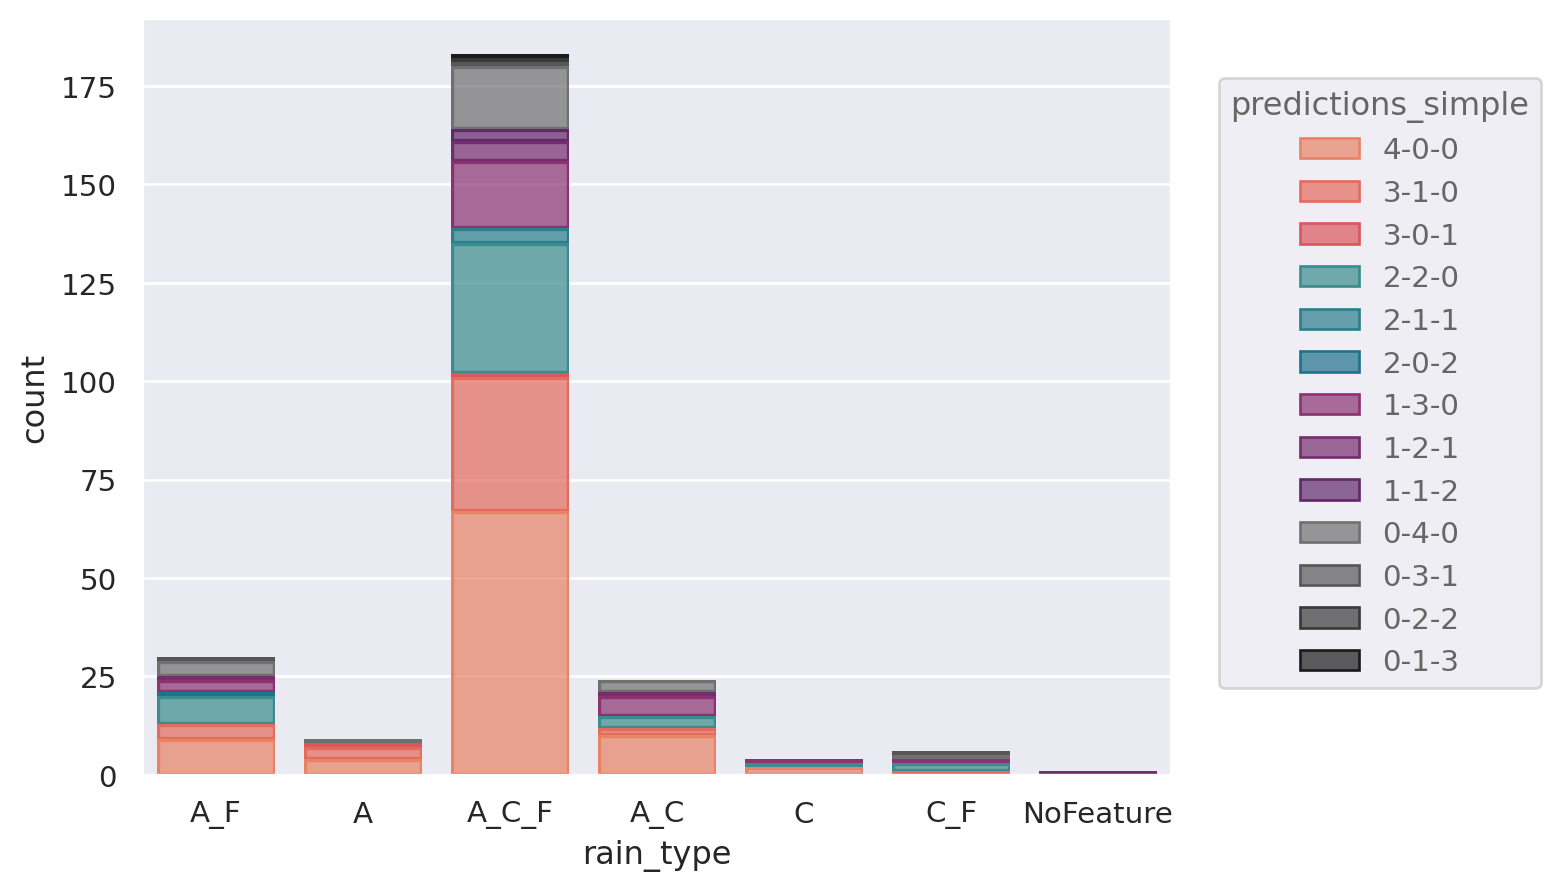

In [103]:
df_features_extremes= df_features.loc[df_features.truth==2]
predictions_per_feature = df_features_extremes.groupby(['rain_type','predictions_simple']).daily_rain.count().unstack()
predictions_per_feature = predictions_per_feature.stack()
df_ = predictions_per_feature.rename('count').reset_index()

(so.Plot(df_.sort_values('predictions_simple', ascending=False), x='rain_type', y='count', color='predictions_simple')
 .add(so.Bar(), so.Stack(),)
 .scale(color=rocket[-9:-6]  + mako[-6:-3] + rocket[-3:] + greys[6:10])
 
)

In [96]:
mako = sns.color_palette('crest', n_colors=10)
rocket = sns.color_palette('flare', n_colors=10)
viridis = sns.color_palette('viridis', n_colors=10)
greys = sns.color_palette('Greys', n_colors=10)


In [ ]:
magma = plt.get_cmap('magma')(np.linspace(0,255,13))
magma = plt.get_cmap('magma')(np.linspace(0,255,13))

array([[1.46200e-03, 4.66000e-04, 1.38660e-02, 1.00000e+00],
       [9.87053e-01, 9.91438e-01, 7.49504e-01, 1.00000e+00],
       [9.87053e-01, 9.91438e-01, 7.49504e-01, 1.00000e+00],
       [9.87053e-01, 9.91438e-01, 7.49504e-01, 1.00000e+00],
       [9.87053e-01, 9.91438e-01, 7.49504e-01, 1.00000e+00],
       [9.87053e-01, 9.91438e-01, 7.49504e-01, 1.00000e+00],
       [9.87053e-01, 9.91438e-01, 7.49504e-01, 1.00000e+00],
       [9.87053e-01, 9.91438e-01, 7.49504e-01, 1.00000e+00],
       [9.87053e-01, 9.91438e-01, 7.49504e-01, 1.00000e+00],
       [9.87053e-01, 9.91438e-01, 7.49504e-01, 1.00000e+00],
       [9.87053e-01, 9.91438e-01, 7.49504e-01, 1.00000e+00],
       [9.87053e-01, 9.91438e-01, 7.49504e-01, 1.00000e+00],
       [9.87053e-01, 9.91438e-01, 7.49504e-01, 1.00000e+00]])

<Axes: xlabel='truth', ylabel='daily_rain'>

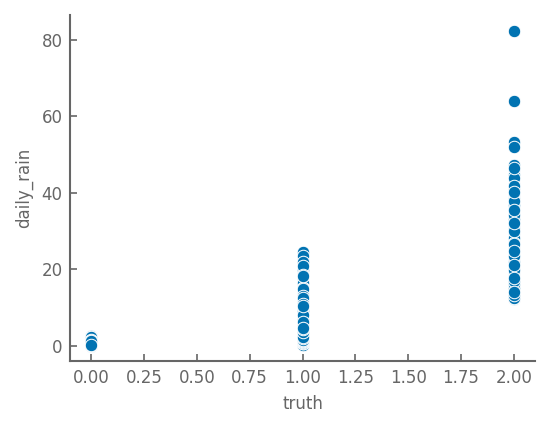

In [19]:
sns.scatterplot(df_features, x='truth', y='daily_rain')

<Axes: xlabel='truth', ylabel='Count'>

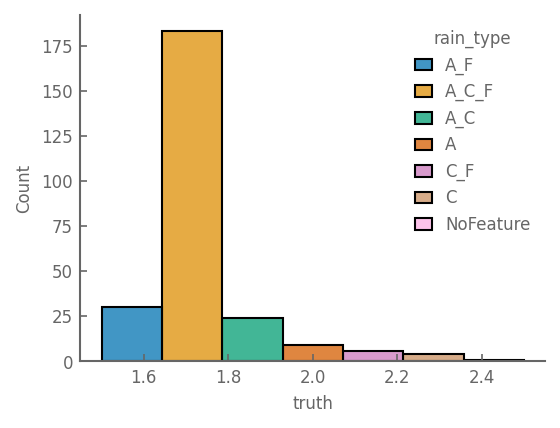

In [26]:
sns.histplot(df_features.loc[df_features.truth==2], x='truth', hue='rain_type', multiple='dodge')

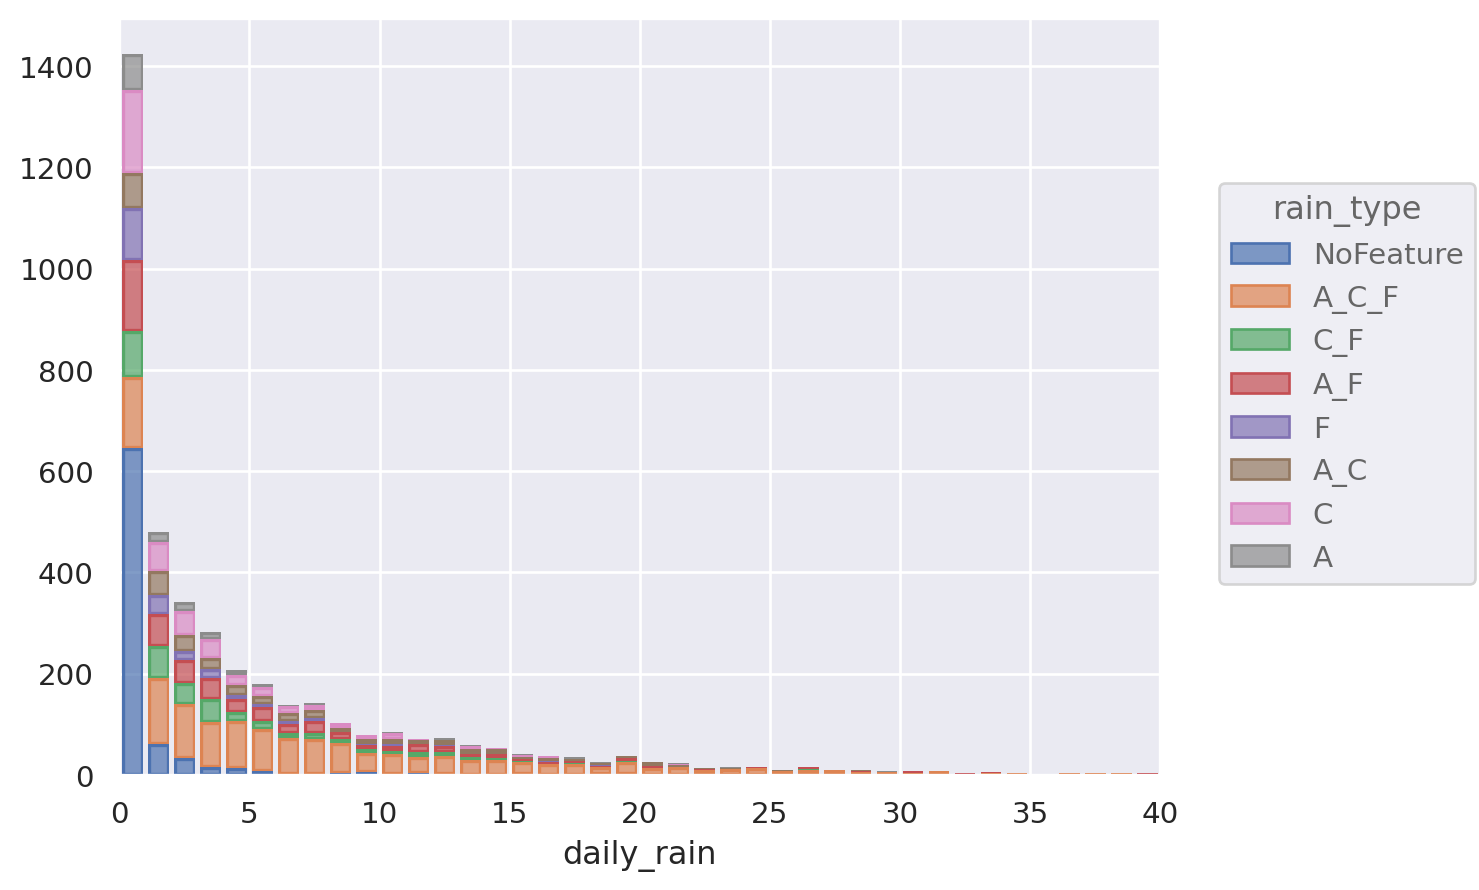

In [17]:
(so.Plot(df_features, color='rain_type', x='daily_rain')
        .add(so.Bar(), so.Hist(bins = np.arange(0,81,1)), so.Stack())
        .limit(x=(0,40))
)